# Experiment: find correlation between market trends and articles published

## Get articles per market

In [13]:
import json
import time
from datetime import datetime
from gnews import GNews
from collections import Counter

INPUT_PATH  = "data/political_markets/search_queries.json"
OUTPUT_PATH = "data/political_markets/market_trends/gnews_raw_results.json"

today = datetime.now()

with open(INPUT_PATH, "r", encoding="utf-8") as f:
    markets = json.load(f)

results = []

for market in markets:
    print(f"\nMarket: {market['question']}")

    start_dt = datetime.fromisoformat(market["start_date"])

    gnews = GNews(
        language="en",
        max_results=100,
        start_date=(start_dt.year, start_dt.month, start_dt.day),
        end_date=(today.year, today.month, today.day),
    )

    market_result = {
        "question":   market["question"],
        "start_date": market["start_date"],
        "end_date":   today.isoformat(),
        "queries":    [],
    }

    for query in market["search_queries"]:
        print(f"  {query}", end=" ... ", flush=True)
        try:
            articles = gnews.get_news(query)
            print(f"{len(articles)} articles")
        except Exception as e:
            print(f"ERROR: {e}")
            articles = []

        market_result["queries"].append({
            "query":    query,
            "articles": articles,
        })
        time.sleep(0.5)

    results.append(market_result)

with open(OUTPUT_PATH, "w", encoding="utf-8") as f:
    json.dump(results, f, indent=2, ensure_ascii=False)

print(f"\nSaved -> {OUTPUT_PATH}")

# ── statistics ────────────────────────────────────────────────────────────────
print("\n" + "="*60)
print("STATISTICS")
print("="*60)

all_sources = Counter()

for market in results:
    articles_flat = [a for q in market["queries"] for a in q["articles"]]
    unique = {a["url"]: a for a in articles_flat}.values()  # deduplicate by URL
    sources = Counter(
        (a["publisher"].get("title") if isinstance(a["publisher"], dict) else a["publisher"])
        for a in unique if a.get("publisher")
    )
    all_sources.update(sources)
    print(f"\n{market['question']}")
    print(f"  total articles (with duplicates) : {len(articles_flat)}")
    print(f"  unique articles                  : {len(unique)}")
    print(f"  top 5 sources: {sources.most_common(5)}")

print(f"\nTop 10 sources across all markets:")
for source, count in all_sources.most_common(10):
    print(f"  {count:4d}  {source}")


Market: Will the AfD be the Berlin State Election Winner?
  AfD Berlin election polls ... 59 articles
  Berlin state election schedule ... 53 articles
  AfD popularity in Berlin ... 45 articles
  Berlin election candidate list ... 65 articles
  AfD Berlin election campaign ... 46 articles
  Berlin state election predictions ... 38 articles
  AfD campaign issues Berlin ... 40 articles
  Berlin election AfD chances ... 26 articles
  AfD vs other parties Berlin election ... 66 articles
  Berlin state election winner ... 50 articles

Market: Strait of Hormuz traffic returns to normal by end of April?
  Strait of Hormuz traffic update ... 100 articles
  Hormuz shipping lane news ... 100 articles
  IMF Portwatch Strait data ... 22 articles
  Strait of Hormuz maritime news ... 100 articles
  Recent Hormuz ship traffic ... 100 articles
  Strait of Hormuz ship traffic update ... 100 articles
  IMF Portwatch Strait of Hormuz data ... 10 articles
  Normal traffic levels Strait of Hormuz ... 75 a

## Deduplicate articles

In [14]:
import json
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
from collections import defaultdict
from datetime import datetime

INPUT_PATH = "data/political_markets/market_trends/gnews_raw_results.json"

with open(INPUT_PATH, "r", encoding="utf-8") as f:
    results = json.load(f)

for market in results:
    seen_urls = set()
    for q in market["queries"]:
        unique_articles = []
        for a in q["articles"]:
            url = a.get("url")
            if url and url not in seen_urls:
                seen_urls.add(url)
                unique_articles.append(a)
        q["articles"] = unique_articles

total = sum(len(a["articles"]) for m in results for a in m["queries"])
print(f"After deduplication: {total} unique articles across all markets")

After deduplication: 1378 unique articles across all markets


## Inspect articles published date

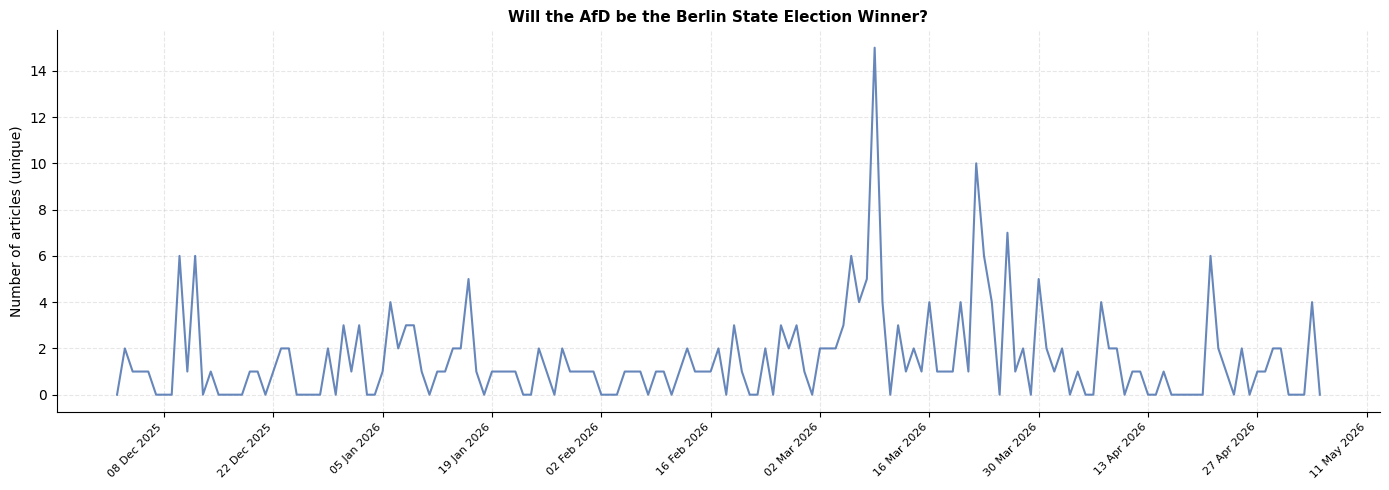

Saved -> data/political_markets/articles_per_day_1_Will_the_AfD_be_the_Berlin_State_Election_Winner?.png


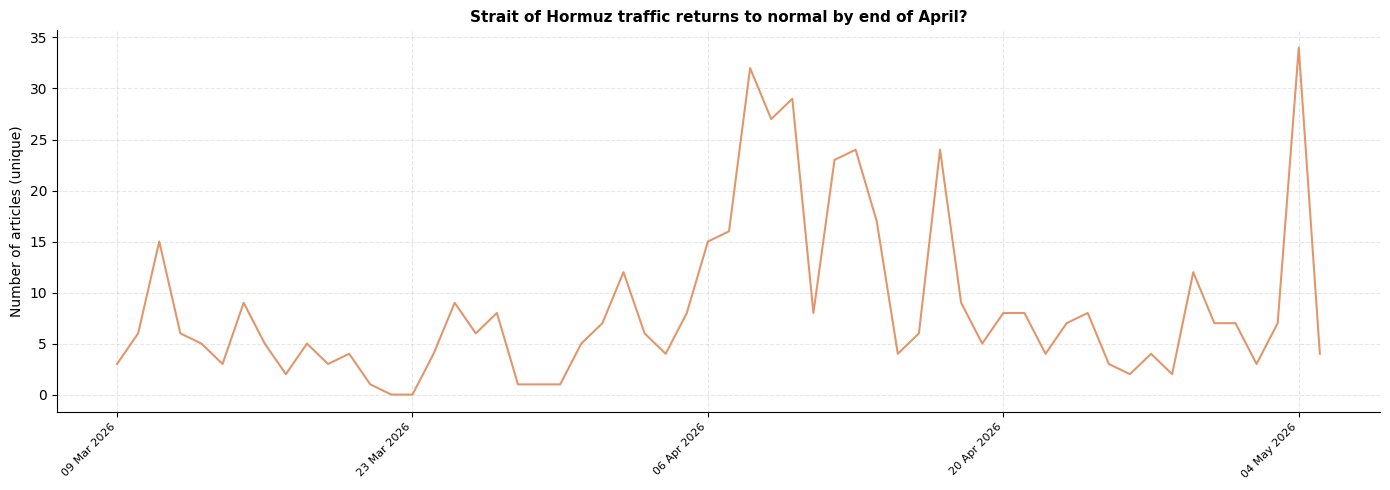

Saved -> data/political_markets/articles_per_day_2_Strait_of_Hormuz_traffic_returns_to_normal_by_end_.png


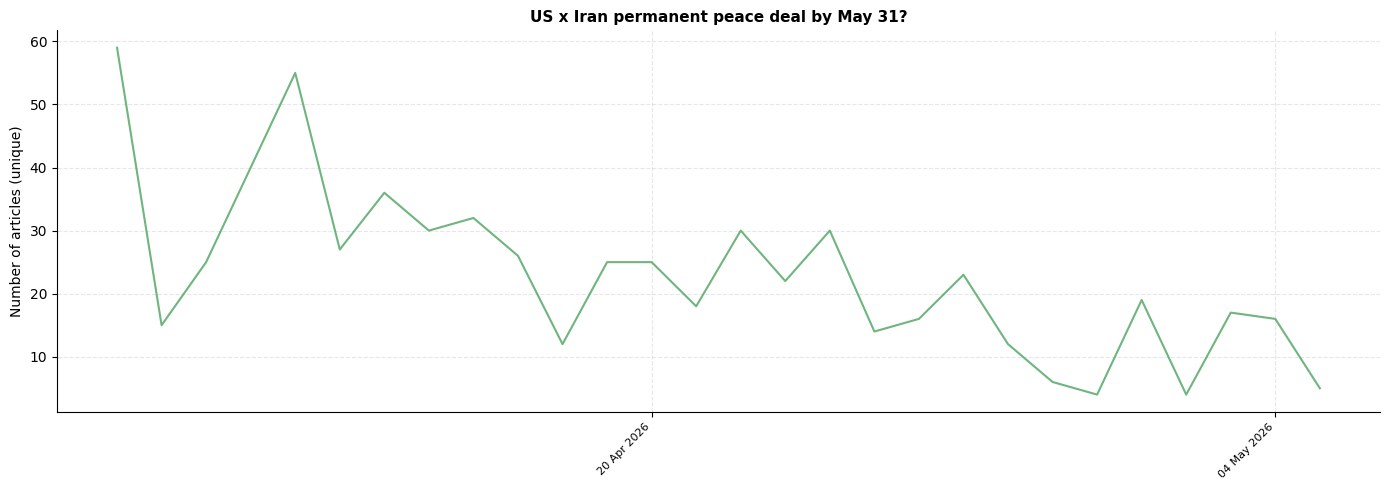

Saved -> data/political_markets/articles_per_day_3_US_x_Iran_permanent_peace_deal_by_May_31?.png


In [15]:
import json
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
from collections import defaultdict
from datetime import datetime, timedelta

INPUT_PATH = "data/political_markets/market_trends/gnews_raw_results.json"

with open(INPUT_PATH, "r", encoding="utf-8") as f:
    results = json.load(f)

# ── deduplicate within each market ────────────────────────────────────────────
for market in results:
    seen_urls = set()
    for q in market["queries"]:
        unique = []
        for a in q["articles"]:
            url = a.get("url")
            if url and url not in seen_urls:
                seen_urls.add(url)
                unique.append(a)
        q["articles"] = unique

# ── count articles per (market, day) ─────────────────────────────────────────
def parse_date(date_str):
    if not date_str:
        return None
    for fmt in ("%a, %d %b %Y %H:%M:%S GMT", "%a, %d %b %Y %H:%M:%S %z"):
        try:
            return datetime.strptime(date_str, fmt)
        except ValueError:
            continue
    return None

market_labels = []
counts = {}  # counts[label][date] = int

for market in results:
    label = market["question"]
    market_labels.append(label)
    day_counts = defaultdict(int)
    for q in market["queries"]:
        for a in q["articles"]:
            dt = parse_date(a.get("published date"))
            if dt:
                day_counts[dt.date()] += 1
    counts[label] = day_counts

# ── build per-market date ranges ─────────────────────────────────────────────
market_start = {m["question"]: datetime.fromisoformat(m["start_date"]).date() for m in results}
overall_end = max(d for label in market_labels for d in counts[label])

# ── plot ──────────────────────────────────────────────────────────────────────
colors = ["#4C72B0", "#DD8452", "#55A868"]

for i, label in enumerate(market_labels):
    start = market_start[label]
    date_range = [start + timedelta(days=j) for j in range((overall_end - start).days + 1)]
    values = [counts[label].get(d, 0) for d in date_range]

    fig, ax = plt.subplots(figsize=(max(14, len(date_range) * 0.08), 5))
    ax.plot(date_range, values, color=colors[i % len(colors)], linewidth=1.5, alpha=0.85)
    ax.set_title(label, fontsize=11, fontweight="bold")
    ax.set_ylabel("Number of articles (unique)")
    ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.MO, interval=2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%d %b %Y"))
    plt.xticks(rotation=45, ha="right", fontsize=8)
    ax.yaxis.get_major_locator().set_params(integer=True)
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="both", linestyle="--", alpha=0.3)
    plt.tight_layout()

    slug = label[:50].replace(" ", "_").replace("/", "-")
    path = f"data/political_markets/articles_per_day_{i+1}_{slug}.png"
    plt.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved -> {path}")